<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.1 Load the libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.2. Import the dataset(Melbourne_housing_FULL.csv):

In [2]:
Data  = pd.read_csv('Melbourne_housing_FULL.csv') # Import the dataset 
Data.head()  # view the first 5 rows of the data

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.3 Check the Dimension of data

In [3]:
Data.shape # see the shape of the data

(34857, 22)

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.4 Check the Information about the data and the datatypes of each respective attributes.

In [4]:
### Check for information about the data
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.5 Check for Null Values and replace the same with mean

In [5]:
Data.isna().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom           8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21097
YearBuilt        19306
CouncilArea          3
Latitude          7976
Longtitude        7976
Regionname           0
Propertycount        3
ParkingArea          0
Price             7610
dtype: int64

In [6]:
Data[Data.BuildingArea.str.isdigit() == False]

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0,Carport,NaN
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.84500,144.95380,Southern Metropolitan,3280.0,Indoor,1455000.0
6,Alphington,5/6 Yarralea St,3,h,S,Jellis,3/9/2016,6.4,3078.0,3.0,...,208.0,inf,2013.0,Darebin City Council,-37.78540,145.03250,Northern Metropolitan,2211.0,Outdoor Stall,1110000.0
11,Altona North,103 Sixth Av,4,h,S,hockingstuart,3/9/2016,11.1,3025.0,NaN,...,NaN,missing,NaN,Hobsons Bay City Council,NaN,NaN,Western Metropolitan,5132.0,Indoor,857500.0
12,Armadale,24 Hume St,3,h,S,RT,3/9/2016,6.3,3143.0,2.0,...,305.0,missing,NaN,Stonnington City Council,-37.85730,145.02260,Southern Metropolitan,4836.0,Parkade,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30551,Melton,14 Musk Ct,3,h,SP,PRDNationwide,27/05/2017,31.7,3337.0,3.0,...,600.0,122.86,1975.0,Melton City Council,-37.68734,144.58001,Western Victoria,3600.0,Parking Pad,295000.0
30606,Noble Park,6 Helen Ct,3,h,SP,Leyton,27/05/2017,22.7,3174.0,3.0,...,587.0,114.2,1960.0,Greater Dandenong City Council,-37.96968,145.16832,South-Eastern Metropolitan,11806.0,Parkade,676000.0
30767,Surrey Hills,25 James St,5,h,S,Jellis,27/05/2017,10.2,3127.0,5.0,...,739.0,266.53,1927.0,Boroondara City Council,-37.81708,145.09566,Southern Metropolitan,5457.0,Carport,2505000.0
30829,Williamstown,2/70 Osborne St,2,u,S,hockingstuart,27/05/2017,6.8,3016.0,2.0,...,169.0,78.54,2000.0,Hobsons Bay City Council,-37.86682,144.90003,Western Metropolitan,6380.0,Detached Garage,880000.0


In [7]:
Data['BuildingArea'].dtype

dtype('O')

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.5a  Checking the dataset missing values

In [8]:
Data['BuildingArea'] = Data['BuildingArea'].astype(str)
Data['BuildingArea'] = Data['BuildingArea'].replace(['inf', 'missing'], np.nan)
Data['BuildingArea'] = pd.to_numeric(Data['BuildingArea'],errors='coerce')

In [9]:
def missing_check(df):
    total = df.isnull().sum().sort_values(ascending=False)   # total number of null values
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)  # percentage of values that are null
    Datatype = df.dtypes
    missing_data = pd.concat([total, percent, Datatype], axis=1, keys=['Total', 'Percent','Datatype'])  # putting the above two together
    return missing_data # return the dataframe
missing_check(Data)

,Total,Percent,Datatype
BuildingArea,21115,0.605761,float64
YearBuilt,19306,0.553863,float64
Landsize,11810,0.338813,float64
Car,8728,0.250394,float64
Bathroom,8226,0.235993,float64
Bedroom,8217,0.235735,float64
Longtitude,7976,0.228821,float64
Latitude,7976,0.228821,float64
Price,7610,0.218321,float64
CouncilArea,3,0.000086,object


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#0e92ea">1.5b Replace NaN with Median for All Non-Object Columns

In [10]:
for col in Data.columns:
    if Data[col].dtype != 'object':   # numeric column
        Data[col] = Data[col].fillna(Data[col].mode())

In [11]:
missing_check(Data)

,Total,Percent,Datatype
BuildingArea,21114,0.605732,float64
YearBuilt,19305,0.553834,float64
Landsize,11810,0.338813,float64
Car,8728,0.250394,float64
Bathroom,8226,0.235993,float64
Bedroom,8217,0.235735,float64
Longtitude,7976,0.228821,float64
Latitude,7976,0.228821,float64
Price,7609,0.218292,float64
CouncilArea,3,0.000086,object


<span style="font-family: Arial; font-weight:bold;font-size:1.7em;color:#00b3e5;">EDA Descriptive Statistics

### Mean

In [12]:
print(Data.mean(numeric_only=True))  # print the mean of each attribute. Ignore "Serial No. as it is not a continuous variable"

Rooms            3.031012e+00
Distance         1.118493e+01
Postcode         3.116063e+03
Bedroom          3.084647e+00
Bathroom         1.624798e+00
Car              1.728845e+00
Landsize         5.935990e+02
BuildingArea     1.602535e+02
YearBuilt        1.965290e+03
Latitude        -3.781063e+01
Longtitude       1.450019e+02
Propertycount    7.572888e+03
Price            1.050157e+06
dtype: float64


### Mode

In [13]:
print(Data['Price'].mode())  # print the mode of each attribute. Ignore "Serial No. as it is not a continuous variable"

0    600000.0
Name: Price, dtype: float64


### Median

In [14]:
print(Data.median(numeric_only=True))  # print the median of each attribute. Ignore "Serial No. as it is not a continuous variable"

Rooms                 3.0000
Distance             10.3000
Postcode           3103.0000
Bedroom               3.0000
Bathroom              2.0000
Car                   2.0000
Landsize            521.0000
BuildingArea        136.0000
YearBuilt          1970.0000
Latitude            -37.8076
Longtitude          145.0078
Propertycount      6763.0000
Price            870000.0000
dtype: float64


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">Univariate Analsyis

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.5a) Plotting the summary mean,mode,median for House pricing

Mean:  1050156.823620082 
Median:  870000.0 
Mode:  600000.0


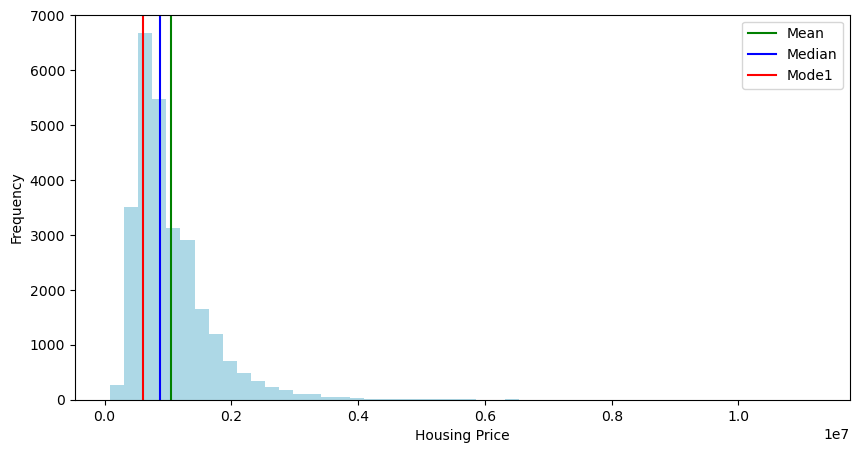

In [15]:
mean=Data['Price'].mean()
median=Data['Price'].median()
mode=Data['Price'].mode()

print('Mean: ',mean,'\nMedian: ',median,'\nMode: ',mode[0])

plt.figure(figsize=(10,5)) # set the figure size
plt.hist(Data['Price'],bins=50,color='lightblue') #Plot the histogram

plt.axvline(mean,color='green',label='Mean')     # Draw lines on the plot for mean median and the two modes we have in GRE Score
plt.axvline(median,color='blue',label='Median')
plt.axvline(mode[0],color='red',label='Mode1')

plt.xlabel('Housing Price')   # label the x-axis
plt.ylabel('Frequency')   # label the y-axis
plt.legend()              # Plot the legend
plt.show()

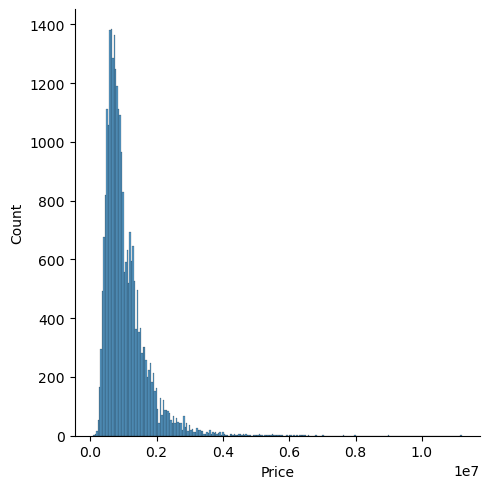

In [16]:
sns.displot(Data['Price'],kind='hist');

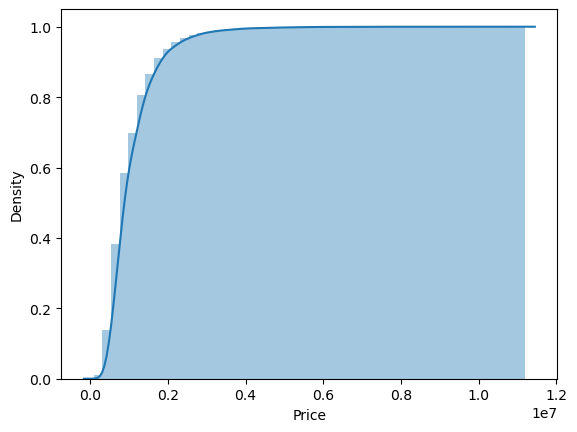

In [17]:
sns.distplot(Data['Price'], hist_kws=dict(cumulative=True), kde_kws=dict(cumulative=True));

 <span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.6 Check the Measures of Dispersion:

In [18]:
Data['Price'].quantile(0.75) - Data['Price'].quantile(0.25)

660000.0

### Range

In [19]:
print(Data['Price'].max() - Data['Price'].min())

11115000.0


### Variance

In [20]:
print(Data.var(numeric_only=True))

Rooms            9.407699e-01
Distance         4.608906e+01
Postcode         1.188621e+04
Bedroom          9.617523e-01
Bathroom         5.244830e-01
Car              1.021658e+00
Landsize         1.155213e+07
BuildingArea     1.610037e+05
YearBuilt        1.393305e+03
Latitude         8.150281e-03
Longtitude       1.444053e-02
Propertycount    1.960798e+07
Price            4.114724e+11
dtype: float64


### Standard Deviation

In [21]:
print(Data.std(numeric_only=True))

Rooms                 0.969933
Distance              6.788892
Postcode            109.023903
Bedroom               0.980690
Bathroom              0.724212
Car                   1.010771
Landsize           3398.841946
BuildingArea        401.252607
YearBuilt            37.326997
Latitude              0.090279
Longtitude            0.120169
Propertycount      4428.090313
Price            641461.155972
dtype: float64


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;">1.7 Check Covariance and Correlation

### Covariance

In [22]:
Data.cov(numeric_only=True)# Prints the covariance of each attribute against every other attribute

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,Longtitude,Propertycount,Price
Rooms,0.940770,1.787864,9.082629e+00,0.891230,0.425279,0.382485,1.221813e+02,6.103670e+01,-4.697425e-01,0.000424,0.011964,-3.078539e+02,2.849504e+05
Distance,1.787864,46.089061,3.564320e+02,1.820819,0.629642,1.678381,1.382438e+03,2.174215e+02,8.374832e+01,-0.062468,0.166393,-5.453381e+02,-9.201847e+05
Postcode,9.082629,356.431993,1.188621e+04,9.832646,9.765642,7.731578,1.478868e+04,2.038162e+03,3.863870e+02,-2.337327,4.887005,8.259377e+03,3.205271e+06
Bedroom,0.891230,1.820819,9.832646e+00,0.961752,0.436677,0.385806,1.239541e+02,6.031862e+01,-7.646669e-02,0.000305,0.012523,-2.274236e+02,2.683201e+05
Bathroom,0.425279,0.629642,9.765642e+00,0.436677,0.524483,0.225790,9.002842e+01,4.368699e+01,4.607570e+00,-0.003873,0.009282,-1.033393e+02,1.966324e+05
Car,0.382485,1.678381,7.731578e+00,0.385806,0.225790,1.021658,1.295039e+02,4.256102e+01,4.751047e+00,-0.000829,0.005748,-4.223906e+01,1.314361e+05
Landsize,122.181295,1382.437825,1.478868e+04,123.954130,90.028421,129.503912,1.155213e+07,1.711791e+05,1.758589e+03,7.542143,-1.025878,-2.675078e+05,8.041004e+07
BuildingArea,61.036704,217.421501,2.038162e+03,60.318618,43.686994,42.561024,1.711791e+05,1.610037e+05,2.283079e+02,0.634975,-0.105324,-4.244257e+04,3.064836e+07
YearBuilt,-0.469743,83.748320,3.863870e+02,-0.076467,4.607570,4.751047,1.758589e+03,2.283079e+02,1.393305e+03,0.308243,-0.099133,3.599229e+03,-8.225301e+06
Latitude,0.000424,-0.062468,-2.337327e+00,0.000305,-0.003873,-0.000829,7.542143e+00,6.349748e-01,3.082434e-01,0.008150,-0.003749,4.358258e+00,-1.289931e+04


### Correlation

In [23]:
Data.corr(numeric_only=True)

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,Longtitude,Propertycount,Price
Rooms,1.000000,0.271511,0.085890,0.946755,0.611826,0.393878,0.037402,0.156229,-0.012757,0.004872,0.103235,-0.071677,0.465252
Distance,0.271511,1.000000,0.481566,0.269524,0.126201,0.241835,0.060862,0.076306,0.323033,-0.100417,0.200946,-0.018140,-0.211343
Postcode,0.085890,0.481566,1.000000,0.089292,0.120080,0.067886,0.040664,0.042440,0.089801,-0.231027,0.362895,0.017108,0.044960
Bedroom,0.946755,0.269524,0.089292,1.000000,0.614892,0.388491,0.037019,0.154158,-0.002031,0.003447,0.106164,-0.053451,0.430297
Bathroom,0.611826,0.126201,0.120080,0.614892,1.000000,0.307518,0.036333,0.147560,0.167943,-0.059183,0.106531,-0.032887,0.429895
Car,0.393878,0.241835,0.067886,0.388491,0.307518,1.000000,0.037829,0.104377,0.128695,-0.009020,0.047213,-0.009617,0.201824
Landsize,0.037402,0.060862,0.040664,0.037019,0.036333,0.037829,1.000000,0.354531,0.044469,0.025318,-0.002582,-0.018195,0.032753
BuildingArea,0.156229,0.076306,0.042440,0.154158,0.147560,0.104377,0.354531,1.000000,0.067806,0.017155,-0.002143,-0.024516,0.100757
YearBuilt,-0.012757,0.323033,0.089801,-0.002031,0.167943,0.128695,0.044469,0.067806,1.000000,0.091593,-0.022175,0.022413,-0.333304
Latitude,0.004872,-0.100417,-0.231027,0.003447,-0.059183,-0.009020,0.025318,0.017155,0.091593,1.000000,-0.345589,0.011112,-0.215606


<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;"> 1.8a. Pairplot for checking the correlation

In [24]:
# sns.pairplot(Data, kind="reg")  # plots scatter plots for every pair of attributes and histograms along the diagonal
# plt.show()

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;"> 1.8b. Heatmap for checking the correlation

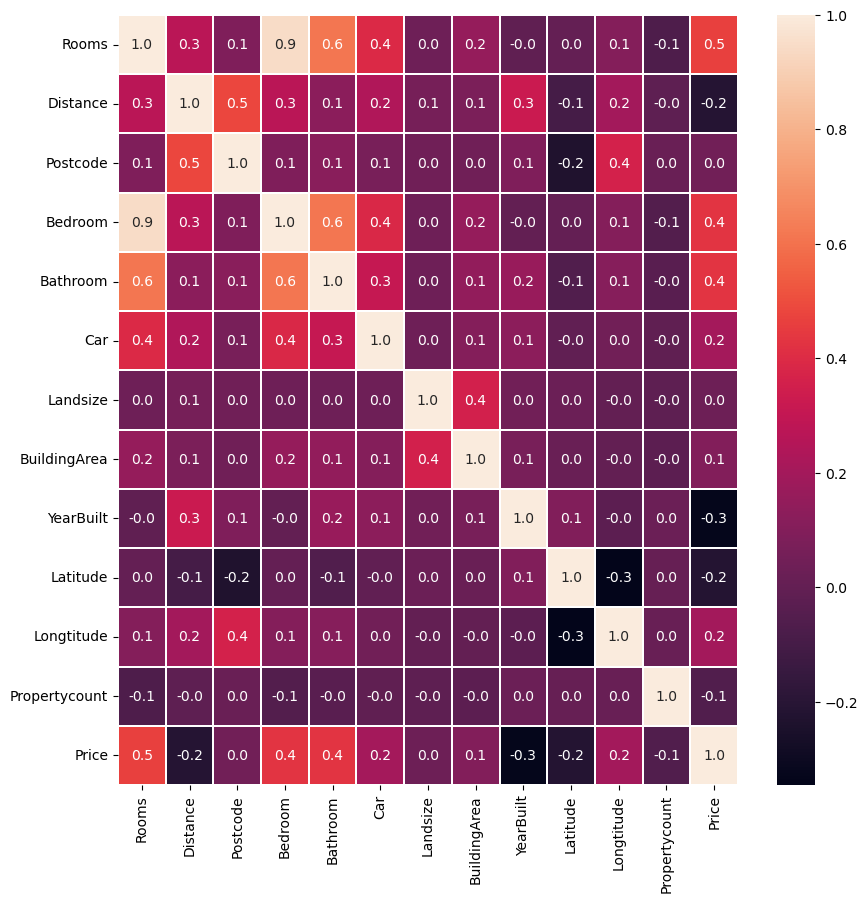

In [25]:
fig,ax = plt.subplots(figsize=(10, 10))   
sns.heatmap(Data.corr(numeric_only=True), ax=ax, annot=True, linewidths=0.05, fmt= '.1f') # the color intensity is based on 
plt.show()

In [26]:
Data.skew(numeric_only=True)   # to measure the skeweness of every attribute

Rooms             0.499097
Distance          1.503586
Postcode          4.018786
Bedroom           1.406366
Bathroom          1.356293
Car               2.095176
Landsize         96.022311
BuildingArea     99.136098
YearBuilt        -1.080970
Latitude         -0.257661
Longtitude       -0.394880
Propertycount     0.992100
Price             2.589011
dtype: float64

# Bivariate Analysis

In [27]:
# Make list of all columns with Object datatype

Obj_dtype = [ col for col in Data.columns if Data[col].dtype == 'object' ]
num_dtype = [ col for col in Data.columns if Data[col].dtype != 'object' ]
print(f"Object columns: {Obj_dtype}")
print(f"Numeric columns: {num_dtype}")

Object columns: ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname', 'ParkingArea']
Numeric columns: ['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount', 'Price']


In [28]:
for col in Obj_dtype:
    print(Data[col].value_counts())
    print()

Suburb
Reservoir         844
Bentleigh East    583
Richmond          552
Glen Iris         491
Preston           485
                 ... 
Avonsleigh          1
Wandin North        1
Ferny Creek         1
Guys Hill           1
viewbank            1
Name: count, Length: 351, dtype: int64

Address
5 Charles St         6
25 William St        4
33 McCracken St      3
14 Northcote St      3
1 Bruce St           3
                    ..
158 Eglinton St      1
220 Cotham Rd        1
302/108 Altona St    1
13 Albermarle St     1
42 Pascoe St         1
Name: count, Length: 34009, dtype: int64

Type
h    23980
u     7297
t     3580
Name: count, dtype: int64

Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

SellerG
Jellis           3359
Nelson           3236
Barry            3235
hockingstuart    2623
Marshall         2027
                 ... 
Knight              1
Allan               1
Black            

<span style="font-family: Arial; font-weight:bold;font-size:1.5em;color:#00b3e5;"> 1.9. Barplot to check the price by RegionName, ParkingArea, Type and Method

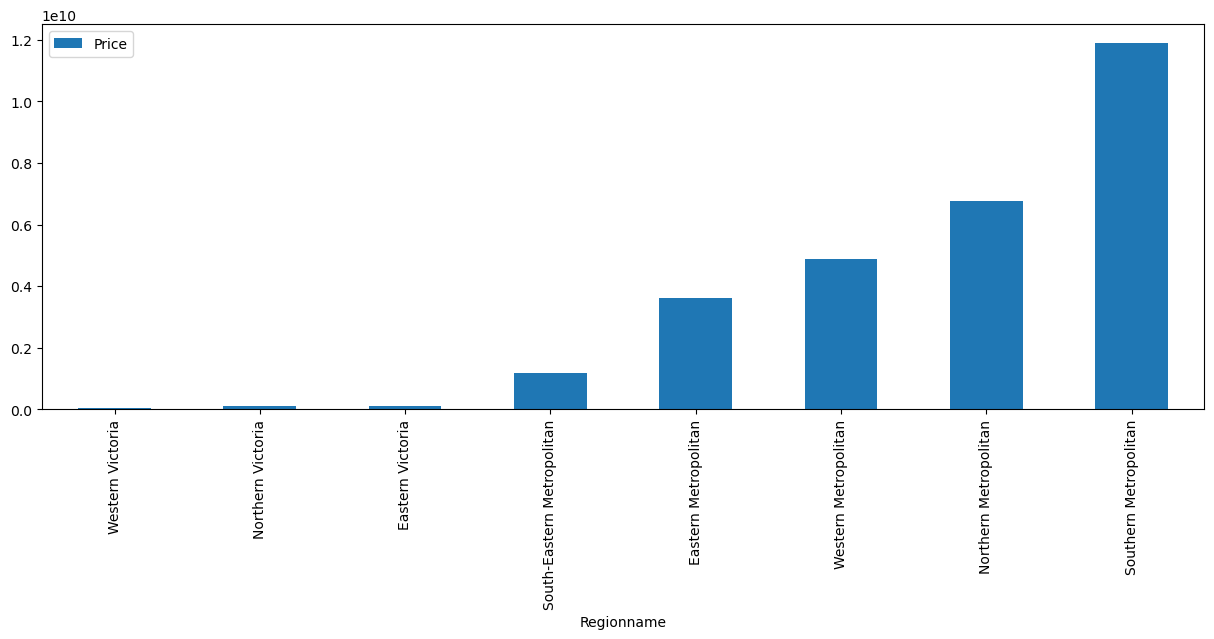

In [29]:
Data.groupby(by='Regionname')['Price'].sum().reset_index().sort_values(['Price']).plot(x='Regionname',
                                                                                      y='Price',
                                                                                      kind='bar',
                                                                                      figsize=(15,5));

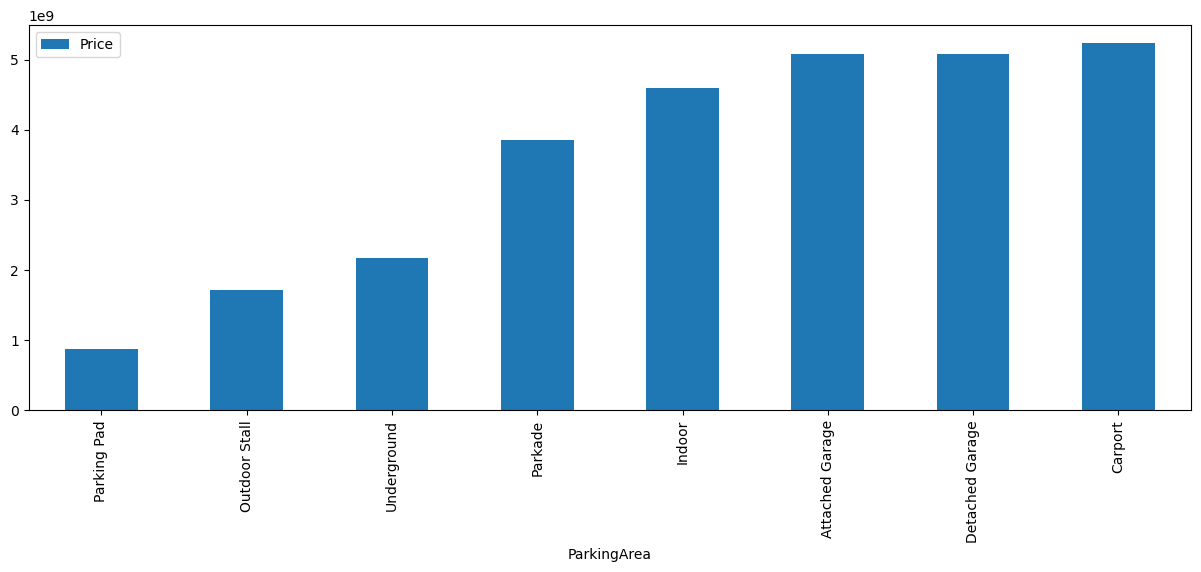

In [30]:
Data.groupby(by='ParkingArea')['Price'].sum().reset_index().sort_values(['Price']).plot(x='ParkingArea',
                                                                                      y='Price',
                                                                                      kind='bar',
                                                                                      figsize=(15,5));

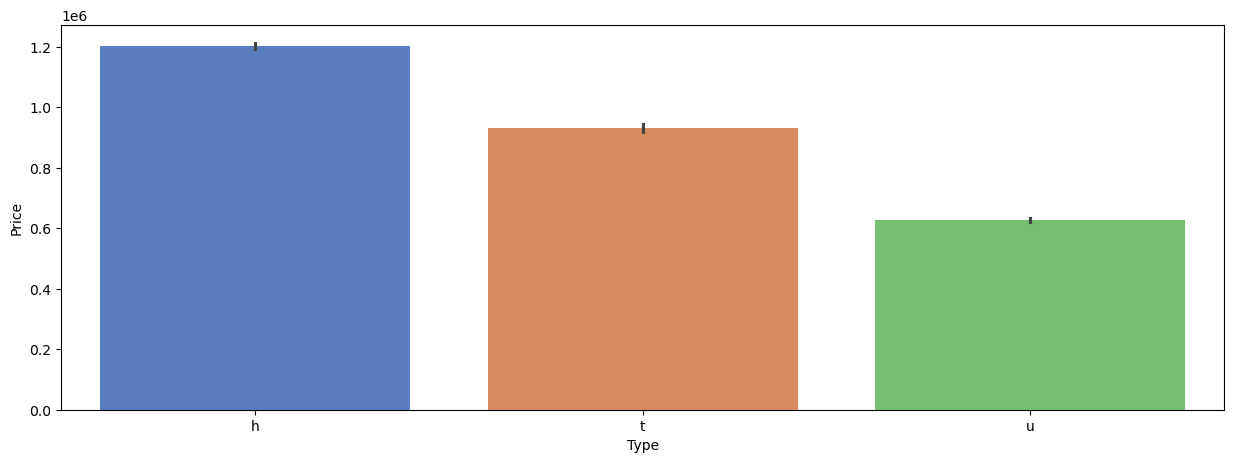

In [31]:
plt.figure(figsize=(15,5))
ax = sns.barplot(x="Type", y="Price", data=Data, palette='muted')

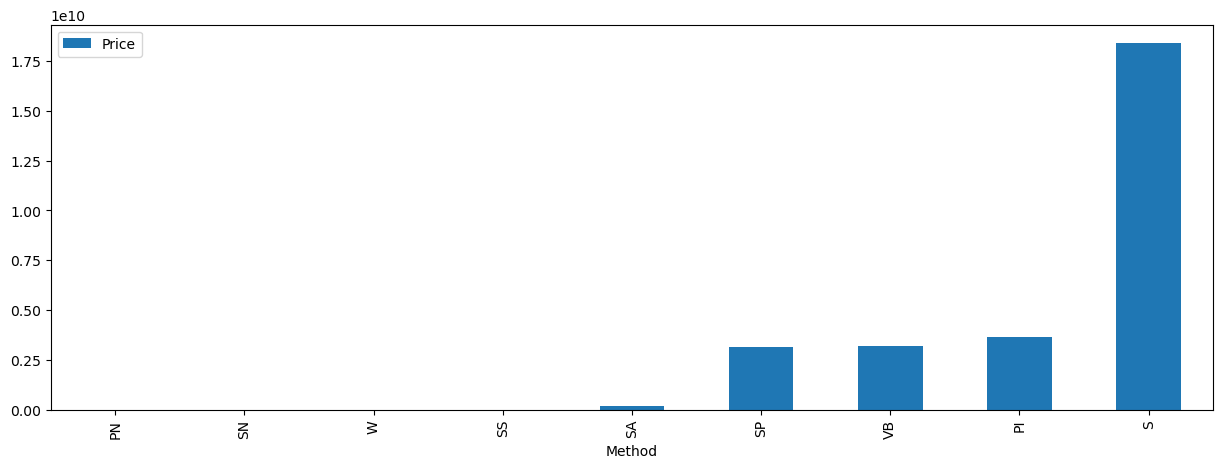

In [32]:
Data.groupby(by='Method')['Price'].sum().reset_index().sort_values(['Price']).plot(x='Method',
                                                                                      y='Price',
                                                                                      kind='bar',
                                                                                      figsize=(15,5));

In [33]:
Parking_area_price = Data['Price'].groupby([Data['ParkingArea'],Data['Type']]).sum().reset_index().sort_values(['Price'],ascending= False)
Parking_area_price

,ParkingArea,Type,Price
3,Carport,h,4.101132e+09
0,Attached Garage,h,3.952988e+09
6,Detached Garage,h,3.946918e+09
9,Indoor,h,3.594852e+09
15,Parkade,h,2.980185e+09
21,Underground,h,1.654387e+09
12,Outdoor Stall,h,1.335194e+09
5,Carport,u,6.773880e+08
8,Detached Garage,u,6.715477e+08
18,Parking Pad,h,6.700322e+08


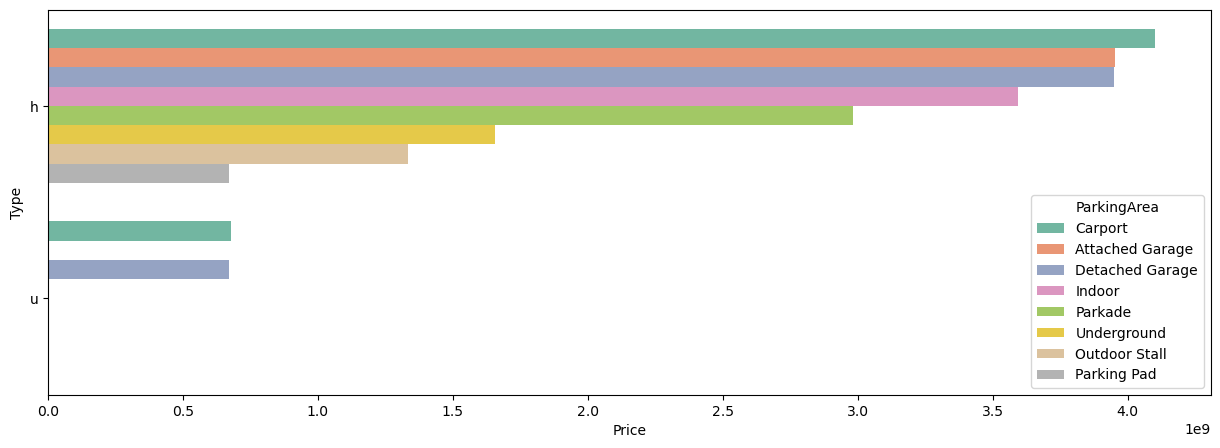

In [34]:
plt.subplots(figsize=(15,5))
sns.barplot(data=Parking_area_price.head(10),y='Type',x='Price',hue='ParkingArea',palette='Set2');

In [35]:
Region_area_price = Data['Price'].groupby([Data['Regionname'],Data['Type']]).sum().reset_index().sort_values(['Price'],ascending= False)
Region_area_price

,Regionname,Type,Price
15,Southern Metropolitan,h,8.727528e+09
6,Northern Metropolitan,h,5.183350e+09
18,Western Metropolitan,h,4.043682e+09
0,Eastern Metropolitan,h,3.055663e+09
17,Southern Metropolitan,u,1.922008e+09
16,Southern Metropolitan,t,1.249357e+09
12,South-Eastern Metropolitan,h,9.691877e+08
8,Northern Metropolitan,u,9.635225e+08
7,Northern Metropolitan,t,6.305895e+08
19,Western Metropolitan,t,4.163726e+08


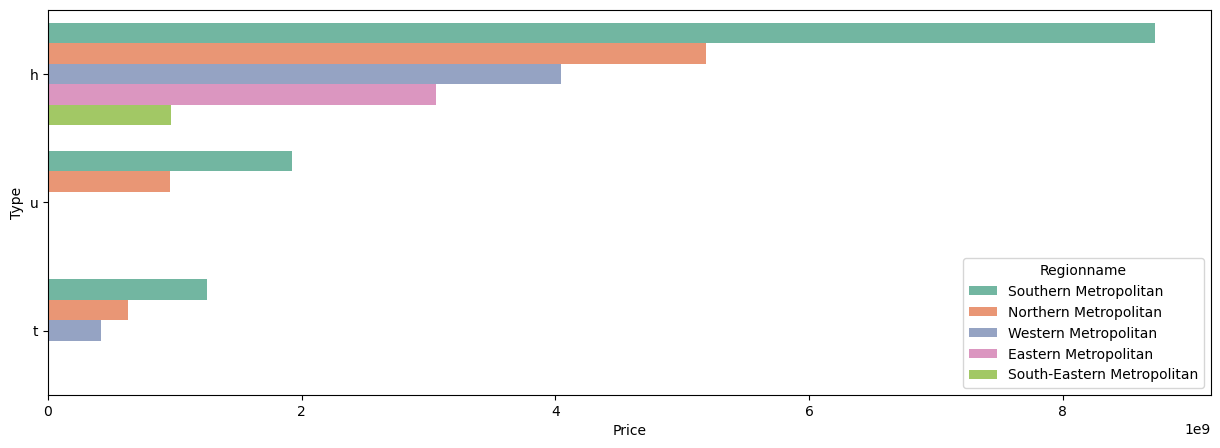

In [36]:
plt.subplots(figsize=(15,5))
sns.barplot(data=Region_area_price.head(10),y='Type',x='Price',hue='Regionname',palette='Set2');

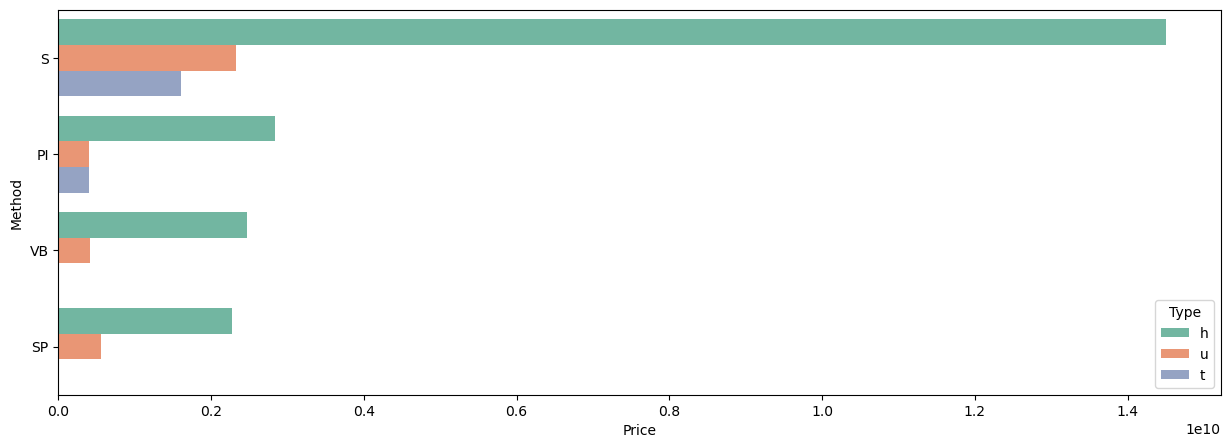

In [37]:
Method_Type_price = Data['Price'].groupby([Data['Method'],Data['Type']]).sum().reset_index().sort_values(['Price'],ascending= False)
plt.subplots(figsize=(15,5))
sns.barplot(data=Method_Type_price.head(10),y='Method',x='Price',hue='Type',palette='Set2');

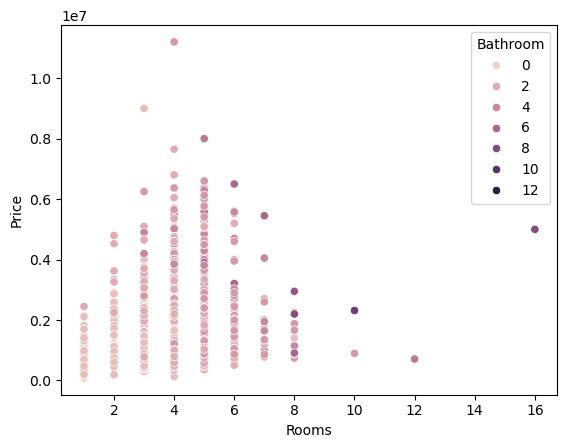

In [38]:
sns.scatterplot(data= Data, y='Price',x='Rooms',hue='Bathroom');

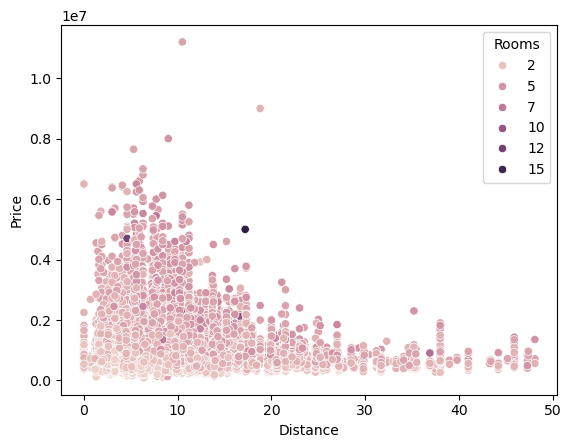

In [39]:
sns.scatterplot(data= Data, y='Price',x='Distance',hue='Rooms');

# <span style="font-family: Arial; font-weight:bold;font-size:1.6em;color:#0e92ea"> Handling non-numeric(Categorical) data

In [40]:
# Make list of all columns with Object datatype

Obj_dtype = [ col for col in Data.columns if Data[col].dtype == 'object' ]
Obj_dtype

['Suburb',
 'Address',
 'Type',
 'Method',
 'SellerG',
 'Date',
 'CouncilArea',
 'Regionname',
 'ParkingArea']

In [41]:
for col in Obj_dtype:
    print(Data[col].value_counts())
    print()

Suburb
Reservoir         844
Bentleigh East    583
Richmond          552
Glen Iris         491
Preston           485
                 ... 
Avonsleigh          1
Wandin North        1
Ferny Creek         1
Guys Hill           1
viewbank            1
Name: count, Length: 351, dtype: int64

Address
5 Charles St         6
25 William St        4
33 McCracken St      3
14 Northcote St      3
1 Bruce St           3
                    ..
158 Eglinton St      1
220 Cotham Rd        1
302/108 Altona St    1
13 Albermarle St     1
42 Pascoe St         1
Name: count, Length: 34009, dtype: int64

Type
h    23980
u     7297
t     3580
Name: count, dtype: int64

Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

SellerG
Jellis           3359
Nelson           3236
Barry            3235
hockingstuart    2623
Marshall         2027
                 ... 
Knight              1
Allan               1
Black            

In [42]:
# Type, Method, regionname and ParkingArea can be label encoded

In [43]:
df_dummies = Data.copy()

In [44]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13743 non-null  float64
 14  YearBuilt      15552 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

In [45]:
## Label Encoding

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df_dummies['RegionID'] = labelencoder.fit_transform(df_dummies.Regionname)
df_dummies['Type'] = labelencoder.fit_transform(df_dummies.Type)
df_dummies['Method'] = labelencoder.fit_transform(df_dummies.Method)
df_dummies['ParkingArea'] = labelencoder.fit_transform(df_dummies.ParkingArea)

In [46]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  int64  
 4   Method         34857 non-null  int64  
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13743 non-null  float64
 14  YearBuilt      15552 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

In [47]:
df_dummies

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price,RegionID
0,Abbotsford,68 Studley St,2,0,6,Jellis,3/9/2016,2.5,3067.0,2.0,...,120.0,1970.0,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0,1,600000.0,2
1,Airport West,154 Halsey Rd,3,1,0,Nelson,3/9/2016,13.5,3042.0,3.0,...,225.0,2016.0,Moonee Valley City Council,-37.71800,144.87800,Western Metropolitan,3464.0,2,840000.0,6
2,Albert Park,105 Kerferd Rd,2,0,2,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,82.0,1900.0,Port Phillip City Council,-37.84590,144.95550,Southern Metropolitan,3280.0,0,1275000.0,5
3,Albert Park,85 Richardson St,2,0,2,Thomson,3/9/2016,3.3,3206.0,2.0,...,NaN,NaN,Port Phillip City Council,-37.84500,144.95380,Southern Metropolitan,3280.0,3,1455000.0,5
4,Alphington,30 Austin St,3,0,4,McGrath,3/9/2016,6.4,3078.0,3.0,...,122.0,2003.0,Darebin City Council,-37.78180,145.01980,Northern Metropolitan,2211.0,5,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Reservoir,18 Elinda Pl,3,2,5,RW,30/09/2017,12.0,3073.0,3.0,...,105.0,1990.0,Darebin City Council,-37.69769,145.02332,Northern Metropolitan,21650.0,5,475000.0,2
34853,Roxburgh Park,14 Stainsby Cr,4,0,2,Raine,30/09/2017,20.6,3064.0,4.0,...,225.0,1995.0,Hume City Council,-37.63665,144.92976,Northern Metropolitan,5833.0,7,591000.0,2
34854,Springvale South,8 Bellbird Ct,4,0,0,Barry,30/09/2017,22.2,3172.0,4.0,...,152.0,1970.0,Greater Dandenong City Council,-37.97037,145.15449,South-Eastern Metropolitan,4054.0,1,NaN,4
34855,Springvale South,30 Waddington Cr,3,0,2,Harcourts,30/09/2017,22.2,3172.0,3.0,...,NaN,NaN,Greater Dandenong City Council,-37.97751,145.14813,South-Eastern Metropolitan,4054.0,2,780500.0,4
